In [1]:
!pip uninstall -y torch torchvision torchaudio

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128


In [2]:
!pip install torch==2.3.1 torchvision==0.18.1 torchaudio==2.3.1 --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 839.6/839.6 MB 2.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 1.9 MB/s eta 0:00:000:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 67.6 MB/s eta 0:00:00:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.2/23.2 MB 76.7 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 875.6/875.6 kB 49.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 103.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 728.5/728.5 MB 2.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 417.9/417.9 MB 4.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 168.4/168.4 MB 10.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 MB 33.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.

In [3]:
import torch

print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.get_device_name(0))

2.3.1+cu118
11.8
Tesla T4


In [1]:
import os
import csv
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import nibabel as nib
import cv2
import pandas as pd
from scipy.ndimage import label as scipy_label
from scipy.spatial.distance import cdist
from scipy.stats import pearsonr
from tqdm import tqdm

# ─────────────────────────────────────────────────────────────
# VIEW CONFIG
# ─────────────────────────────────────────────────────────────
VIEW_CONFIG = {
    "SAX_TR": {"num_classes": 4, "lv_label": 2},   # 0=bg,1=LV-myo,2=LV-cav,3=RV-cav
    "2CH_TR": {"num_classes": 3, "lv_label": 1},   # 0=bg,1=LV-cav,2=LV-myo
    "4CH_TR": {"num_classes": 6, "lv_label": 1},   # 0=bg,1=LV-cav,2=LV-myo,3=RV-cav,4=RA,5=LA
}

# ─────────────────────────────────────────────────────────────
# OUTPUT DIRECTORY — CSVs and .pth files land here
# ─────────────────────────────────────────────────────────────
OUTPUT_DIR = "/kaggle/working"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [2]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=4):
        super().__init__()
        self.d1, self.p1 = DoubleConv(in_channels, 64),  nn.MaxPool2d(2)
        self.d2, self.p2 = DoubleConv(64, 128),           nn.MaxPool2d(2)
        self.d3, self.p3 = DoubleConv(128, 256),          nn.MaxPool2d(2)
        self.d4, self.p4 = DoubleConv(256, 512),          nn.MaxPool2d(2)
        self.bn          = DoubleConv(512, 1024)

        self.u4 = nn.ConvTranspose2d(1024, 512, 2, stride=2); self.c4 = DoubleConv(1024, 512)
        self.u3 = nn.ConvTranspose2d(512,  256, 2, stride=2); self.c3 = DoubleConv(512,  256)
        self.u2 = nn.ConvTranspose2d(256,  128, 2, stride=2); self.c2 = DoubleConv(256,  128)
        self.u1 = nn.ConvTranspose2d(128,   64, 2, stride=2); self.c1 = DoubleConv(128,   64)
        self.final = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        d1 = self.d1(x);           d2 = self.d2(self.p1(d1))
        d3 = self.d3(self.p2(d2)); d4 = self.d4(self.p3(d3))
        bn = self.bn(self.p4(d4))
        x = self.c4(torch.cat([self.u4(bn), d4], 1))
        x = self.c3(torch.cat([self.u3(x),  d3], 1))
        x = self.c2(torch.cat([self.u2(x),  d2], 1))
        x = self.c1(torch.cat([self.u1(x),  d1], 1))
        return self.final(x)

In [3]:
class DiceCELoss(nn.Module):
    def __init__(self, num_classes, ce_w=0.5, dice_w=0.5, smooth=1e-5):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
        self.num_classes = num_classes
        self.smooth = smooth
        self.ce_w = ce_w; self.dice_w = dice_w

    def forward(self, logits, targets):
        ce_loss = self.ce(logits, targets)
        probs   = F.softmax(logits, dim=1)
        t_oh    = F.one_hot(targets, self.num_classes).permute(0, 3, 1, 2).float()
        dice = 0.0
        for c in range(1, self.num_classes):
            p = probs[:, c]; t = t_oh[:, c]
            dice += 1 - (2*(p*t).sum() + self.smooth) / (p.sum() + t.sum() + self.smooth)
        return self.ce_w * ce_loss + self.dice_w * dice / (self.num_classes - 1)

In [4]:
class CineMRIDataset(Dataset):
    def __init__(self, root_dir, view="SAX_TR", img_size=256, augment=False):
        self.img_dir  = os.path.join(root_dir, view, "image")
        self.mask_dir = os.path.join(root_dir, view, "anno")
        self.img_size = img_size
        self.augment  = augment
        self.view     = view

        self.lvef_map = {}
        xlsx_path = os.path.join(root_dir, "dataset.xlsx")
        sheet_map = {"SAX_TR": "SAX", "2CH_TR": "2CH", "4CH_TR": "4CH"}
        if os.path.exists(xlsx_path) and view in sheet_map:
            try:
                df = pd.read_excel(xlsx_path, sheet_name=sheet_map[view])
                if "LVEF" in df.columns and "image_path" in df.columns:
                    for _, row in df.iterrows():
                        stem = os.path.splitext(os.path.basename(str(row["image_path"])))[0]
                        stem = stem.replace(".nii", "")
                        self.lvef_map[stem] = float(row["LVEF"])
            except Exception as e:
                print(f"[WARN] Could not load LVEF from xlsx: {e}")

        self.files   = sorted(os.listdir(self.img_dir))
        self.samples = []

        for file in self.files:
            img_path  = os.path.join(self.img_dir,  file)
            mask_path = os.path.join(self.mask_dir, file)
            stem      = file.replace(".nii.gz", "").replace(".nii", "")
            lvef      = self.lvef_map.get(stem, float("nan"))

            img = nib.load(img_path).get_fdata()
            if img.ndim == 4:
                H, W, T, S = img.shape
                for s in range(S):
                    for t in range(T):
                        self.samples.append((img_path, mask_path, t, s, lvef))
            elif img.ndim == 3:
                H, W, T = img.shape
                for t in range(T):
                    self.samples.append((img_path, mask_path, t, None, lvef))

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        img_path, mask_path, t, s, lvef = self.samples[idx]
        img  = nib.load(img_path).get_fdata()
        mask = nib.load(mask_path).get_fdata()

        if img.ndim == 4:
            img  = img[:, :, t, s]
            mask = mask[:, :, t, s]
        else:
            img  = img[:, :, t]
            mask = mask[:, :, t]

        img = (img - img.mean()) / (img.std() + 1e-8)
        img  = cv2.resize(img,  (self.img_size, self.img_size))
        mask = cv2.resize(mask, (self.img_size, self.img_size),
                          interpolation=cv2.INTER_NEAREST)

        if self.augment:
            img, mask = self._augment(img, mask)

        img  = torch.tensor(img,  dtype=torch.float32).unsqueeze(0)
        mask = torch.tensor(mask, dtype=torch.long)
        return img, mask, torch.tensor(lvef, dtype=torch.float32)

    def _augment(self, img, mask):
        if np.random.rand() > 0.5:
            img, mask = np.fliplr(img).copy(), np.fliplr(mask).copy()
        if np.random.rand() > 0.5:
            img, mask = np.flipud(img).copy(), np.flipud(mask).copy()
        k = np.random.randint(0, 4)
        img, mask = np.rot90(img, k).copy(), np.rot90(mask, k).copy()
        alpha = np.random.uniform(0.8, 1.2)
        beta  = np.random.uniform(-0.1, 0.1)
        img   = np.clip(alpha * img + beta, img.min(), img.max())
        return img, mask

In [5]:
def dice_score(preds, targets, num_classes):
    preds = torch.argmax(preds, dim=1)
    dice  = 0.0
    for c in range(1, num_classes):
        p = (preds   == c).float()
        t = (targets == c).float()
        dice += (2*(p*t).sum() + 1e-5) / (p.sum() + t.sum() + 1e-5)
    return dice / (num_classes - 1)


def hausdorff95_asd(pred_np, gt_np, num_classes):
    from scipy.ndimage import binary_erosion
    hds, asds = [], []
    for c in range(1, num_classes):
        p = (pred_np == c); t = (gt_np == c)
        if p.sum() == 0 or t.sum() == 0:
            continue
        p_surf = np.column_stack(np.where(p & ~binary_erosion(p)))
        t_surf = np.column_stack(np.where(t & ~binary_erosion(t)))
        if len(p_surf) == 0 or len(t_surf) == 0:
            continue
        D = cdist(p_surf, t_surf)
        d_pt = D.min(axis=1); d_tp = D.min(axis=0)
        hds.append(max(np.percentile(d_pt, 95), np.percentile(d_tp, 95)))
        asds.append((d_pt.mean() + d_tp.mean()) / 2.0)
    return (np.mean(hds), np.mean(asds)) if hds else (float("nan"), float("nan"))


def keep_largest_component(pred, num_classes):
    clean = np.zeros_like(pred)
    for c in range(1, num_classes):
        binary = (pred == c)
        labeled, n = scipy_label(binary)
        if n == 0: continue
        largest = np.argmax([(labeled == i).sum() for i in range(1, n+1)]) + 1
        clean[labeled == largest] = c
    return clean


def estimate_lv_pixels(pred_np, lv_label):
    return float((pred_np == lv_label).sum())

In [6]:
def train_view(root_dir, view="SAX_TR", num_epochs=15, batch_size=32, lr=1e-4, img_size=256):
    cfg         = VIEW_CONFIG[view]
    num_classes = cfg["num_classes"]
    lv_label    = cfg["lv_label"]

    print(f"\n{'='*60}")
    print(f"  Training view: {view}  |  classes: {num_classes}  |  LV label: {lv_label}")
    print(f"{'='*60}")

    # ── CSV log setup ─────────────────────────────────────────
    csv_path = os.path.join(OUTPUT_DIR, f"metrics_{view}.csv")
    csv_file = open(csv_path, "w", newline="")
    csv_writer = csv.writer(csv_file)
    csv_writer.writerow(["epoch", "train_loss", "val_loss", "val_dice", "val_hd95", "val_asd", "ef_pcc"])
    print(f"  Logging metrics → {csv_path}")

    # ── Datasets ──────────────────────────────────────────────
    train_ds = CineMRIDataset(root_dir, view=view, img_size=img_size, augment=True)
    val_ds   = CineMRIDataset(root_dir, view=view, img_size=img_size, augment=False)

    indices = list(range(len(train_ds)))
    np.random.shuffle(indices)
    split = int(0.8 * len(indices))

    train_loader = DataLoader(Subset(train_ds, indices[:split]),
                              batch_size=batch_size, shuffle=True,  num_workers=4, pin_memory=True)
    val_loader   = DataLoader(Subset(val_ds,   indices[split:]),
                              batch_size=batch_size, shuffle=False, num_workers=4, pin_memory=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model  = UNet(in_channels=1, out_channels=num_classes)
    if torch.cuda.device_count() > 1:
        print(f"  Using {torch.cuda.device_count()} GPUs")
        model = nn.DataParallel(model)
    model = model.to(device)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = DiceCELoss(num_classes=num_classes)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=1e-6)

    best_dice = 0.0

    for epoch in range(num_epochs):

        # ── Train ────────────────────────────────────────────
        model.train()
        train_loss = 0.0
        for imgs, masks, _ in tqdm(train_loader, desc=f"[{view}] Epoch {epoch+1}/{num_epochs} train"):
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)
            loss  = criterion(preds, masks)
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            train_loss += loss.item()
        scheduler.step()
        avg_train_loss = train_loss / len(train_loader)

        # ── Validate ─────────────────────────────────────────
        model.eval()
        val_loss = 0.0; val_dice = 0.0
        val_hd   = 0.0; val_asd  = 0.0; hd_n = 0
        pred_lv_vols, gt_lvefs = [], []

        with torch.no_grad():
            for imgs, masks, lvefs in tqdm(val_loader, desc=f"[{view}] Epoch {epoch+1}/{num_epochs} val"):
                imgs, masks = imgs.to(device), masks.to(device)
                preds = model(imgs)
                val_loss += criterion(preds, masks).item()
                val_dice += dice_score(preds, masks, num_classes).item()

                pred_np = torch.argmax(preds, 1).cpu().numpy()
                mask_np = masks.cpu().numpy()

                for b in range(pred_np.shape[0]):
                    p_clean = keep_largest_component(pred_np[b], num_classes)
                    hd, asd = hausdorff95_asd(p_clean, mask_np[b], num_classes)
                    if not np.isnan(hd):
                        val_hd += hd; val_asd += asd; hd_n += 1
                    lv_px    = estimate_lv_pixels(p_clean, lv_label)
                    lvef_val = lvefs[b].item()
                    if not np.isnan(lvef_val):
                        pred_lv_vols.append(lv_px)
                        gt_lvefs.append(lvef_val)

        n = len(val_loader)
        avg_val_loss = val_loss / n
        avg_dice     = val_dice / n
        avg_hd       = val_hd  / hd_n if hd_n > 0 else float("nan")
        avg_asd      = val_asd / hd_n if hd_n > 0 else float("nan")

        if view == "SAX_TR" and len(gt_lvefs) >= 2:
            pcc, _ = pearsonr(pred_lv_vols, gt_lvefs)
        else:
            pcc = float("nan")

        # ── Log to CSV ───────────────────────────────────────
        csv_writer.writerow([epoch + 1, avg_train_loss, avg_val_loss,
                             avg_dice, avg_hd, avg_asd, pcc])
        csv_file.flush()   # write immediately so you can inspect mid-training

        print(f"\n[{view}] Epoch {epoch+1:02d}/{num_epochs}")
        print(f"  Train Loss : {avg_train_loss:.4f}")
        print(f"  Val   Loss : {avg_val_loss:.4f}")
        print(f"  Val Dice   : {avg_dice:.4f}  ↑")
        print(f"  Val HD95   : {avg_hd:.2f}  ↓")
        print(f"  Val ASD    : {avg_asd:.2f}  ↓")
        if not np.isnan(pcc):
            print(f"  EF PCC     : {pcc:.4f}  ↑")
        else:
            print(f"  EF PCC     : N/A")

        if avg_dice > best_dice:
            best_dice = avg_dice
            save_path = os.path.join(OUTPUT_DIR, f"unet_{view}_best.pth")
            torch.save(
                model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict(),
                save_path
            )
            print(f"  ✓ Best model saved → {save_path}")

    # Final save
    torch.save(
        model.module.state_dict() if isinstance(model, nn.DataParallel) else model.state_dict(),
        os.path.join(OUTPUT_DIR, f"unet_{view}_best.pth")
    )
    csv_file.close()
    print(f"\n  Metrics saved → {csv_path}")
    return model

In [12]:
ROOT = "/kaggle/input/datasets/youssefsharabas/cinemultii"

for view in ["2CH_TR", "4CH_TR","SAX_TR"]:
    train_view(ROOT, view=view, num_epochs=15, batch_size=32)


  Training view: 2CH_TR  |  classes: 3  |  LV label: 1
  Logging metrics → /kaggle/working/metrics_2CH_TR.csv
  Using 2 GPUs


[2CH_TR] Epoch 1/15 val: 100%|██████████| 54/54 [00:32<00:00,  1.67it/s]



[2CH_TR] Epoch 01/15
  Train Loss : 0.4603
  Val   Loss : 0.3193
  Val Dice   : 0.8568  ↑
  Val HD95   : 10.98  ↓
  Val ASD    : 3.50  ↓
  EF PCC     : N/A
  ✓ Best model saved → /kaggle/working/unet_2CH_TR_best.pth


[2CH_TR] Epoch 2/15 val: 100%|██████████| 54/54 [00:31<00:00,  1.71it/s]



[2CH_TR] Epoch 02/15
  Train Loss : 0.2549
  Val   Loss : 0.2038
  Val Dice   : 0.8769  ↑
  Val HD95   : 9.35  ↓
  Val ASD    : 2.99  ↓
  EF PCC     : N/A
  ✓ Best model saved → /kaggle/working/unet_2CH_TR_best.pth


...


[SAX_TR] Epoch 13/15
  Train Loss : 0.0546
  Val   Loss : 0.0558
  Val Dice   : 0.9321  ↑
  Val HD95   : 4.22  ↓
  Val ASD    : 1.45  ↓
  EF PCC     : N/A
  ✓ Best model saved → /kaggle/working/unet_SAX_TR_best.pth


[SAX_TR] Epoch 14/15 val: 100%|██████████| 186/186 [02:09<00:00,  1.43it/s]



[SAX_TR] Epoch 14/15
  Train Loss : 0.0537
  Val   Loss : 0.0550
  Val Dice   : 0.9330  ↑
  Val HD95   : 4.13  ↓
  Val ASD    : 1.42  ↓
  EF PCC     : N/A
  ✓ Best model saved → /kaggle/working/unet_SAX_TR_best.pth


[SAX_TR] Epoch 15/15 val: 100%|██████████| 186/186 [02:16<00:00,  1.36it/s]



[SAX_TR] Epoch 15/15
  Train Loss : 0.0530
  Val   Loss : 0.0545
  Val Dice   : 0.9336  ↑
  Val HD95   : 4.11  ↓
  Val ASD    : 1.41  ↓
  EF PCC     : N/A
  ✓ Best model saved → /kaggle/working/unet_SAX_TR_best.pth

  Metrics saved → /kaggle/working/metrics_SAX_TR.csv


In [8]:
import os

# ── Dataset ───────────────────────────────────────────────────────────────────
ROOT         = "/kaggle/input/datasets/youssefsharabas/cinemultii"
SAX_IMG_DIR  = os.path.join(ROOT, "SAX_TR", "image")

# ── Model ─────────────────────────────────────────────────────────────────────
SAX_MODEL    = "/kaggle/working/unet_SAX_TR_best.pth"

# ── Training metrics CSV (for confidence summary) ─────────────────────────────
SAX_CSV      = "/kaggle/working/metrics_SAX_TR.csv"   # produced by training notebook

# ── Output ────────────────────────────────────────────────────────────────────
OUTPUT_DIR   = "/kaggle/working"
OUTPUT_JSON  = os.path.join(OUTPUT_DIR, "ef_predictions.json")

# ── SAX segmentation constants ────────────────────────────────────────────────
LV_LABEL     = 2          # SAX class 2 = LV cavity
NUM_CLASSES  = 4          # SAX has 4 classes
IMG_SIZE     = 256        # model input resolution
BATCH_SIZE   = 64

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Paths configured.")

Paths configured.


In [9]:
import json
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import nibabel as nib
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [10]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=4):
        super().__init__()
        self.d1, self.p1 = DoubleConv(in_channels, 64),  nn.MaxPool2d(2)
        self.d2, self.p2 = DoubleConv(64,  128),          nn.MaxPool2d(2)
        self.d3, self.p3 = DoubleConv(128, 256),          nn.MaxPool2d(2)
        self.d4, self.p4 = DoubleConv(256, 512),          nn.MaxPool2d(2)
        self.bn          = DoubleConv(512, 1024)
        self.u4 = nn.ConvTranspose2d(1024, 512, 2, stride=2); self.c4 = DoubleConv(1024, 512)
        self.u3 = nn.ConvTranspose2d(512,  256, 2, stride=2); self.c3 = DoubleConv(512,  256)
        self.u2 = nn.ConvTranspose2d(256,  128, 2, stride=2); self.c2 = DoubleConv(256,  128)
        self.u1 = nn.ConvTranspose2d(128,   64, 2, stride=2); self.c1 = DoubleConv(128,   64)
        self.final = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        d1 = self.d1(x);           d2 = self.d2(self.p1(d1))
        d3 = self.d3(self.p2(d2)); d4 = self.d4(self.p3(d3))
        bn = self.bn(self.p4(d4))
        x  = self.c4(torch.cat([self.u4(bn), d4], 1))
        x  = self.c3(torch.cat([self.u3(x),  d3], 1))
        x  = self.c2(torch.cat([self.u2(x),  d2], 1))
        x  = self.c1(torch.cat([self.u1(x),  d1], 1))
        return self.final(x)

In [11]:
model = UNet(in_channels=1, out_channels=NUM_CLASSES)
state = torch.load(SAX_MODEL, map_location=DEVICE)

# Strip DataParallel prefix if present
if any(k.startswith("module.") for k in state.keys()):
    state = {k.replace("module.", "", 1): v for k, v in state.items()}

model.load_state_dict(state)
if torch.cuda.device_count() > 1:
    model = nn.DataParallel(model)
model = model.to(DEVICE)
model.eval()

total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"SAX U-Net loaded — {total_params:.1f}M parameters")

SAX U-Net loaded — 31.0M parameters


In [12]:
if os.path.exists(SAX_CSV):
    df_csv = pd.read_csv(SAX_CSV)
    best_epoch = df_csv.loc[df_csv["val_dice"].idxmax()]
    print("SAX model training summary (from metrics CSV)")
    print(f"  Best epoch  : {int(best_epoch['epoch'])} / {len(df_csv)}")
    print(f"  Val Dice    : {best_epoch['val_dice']:.4f}")
    print(f"  Val HD95    : {best_epoch['val_hd95']:.2f} px")
    print(f"  Val ASD     : {best_epoch['val_asd']:.2f} px")
    if not np.isnan(best_epoch["ef_pcc"]):
        print(f"  EF PCC      : {best_epoch['ef_pcc']:.4f}")
else:
    print(f"[INFO] CSV not found at {SAX_CSV} — skipping summary.")

SAX model training summary (from metrics CSV)
  Best epoch  : 15 / 15
  Val Dice    : 0.9333
  Val HD95    : 4.09 px
  Val ASD     : 1.39 px


In [13]:
class SAXInferenceDataset(Dataset):
    """
    Iterates over every (patient, time-frame, slice) triple in the SAX image folder.
    Returns: (image_tensor, patient_id, frame_idx, slice_idx)
    """
    def __init__(self, img_dir, img_size=256):
        self.img_size = img_size
        self.samples  = []   # (file_path, patient_id, t, s)

        for fname in sorted(os.listdir(img_dir)):
            if not (fname.endswith(".nii.gz") or fname.endswith(".nii")):
                continue
            fpath      = os.path.join(img_dir, fname)
            patient_id = fname.replace(".nii.gz", "").replace(".nii", "")
            vol        = nib.load(fpath).get_fdata()

            if vol.ndim == 4:
                H, W, T, S = vol.shape
                for t in range(T):
                    for s in range(S):
                        self.samples.append((fpath, patient_id, t, s))
            elif vol.ndim == 3:
                H, W, T = vol.shape
                for t in range(T):
                    self.samples.append((fpath, patient_id, t, 0))

        print(f"Dataset: {len(set(s[1] for s in self.samples))} patients, "
              f"{len(self.samples):,} total slices")

    def __len__(self): return len(self.samples)

    def __getitem__(self, idx):
        fpath, patient_id, t, s = self.samples[idx]
        vol = nib.load(fpath).get_fdata()

        if vol.ndim == 4:
            sl = vol[:, :, t, s]
        else:
            sl = vol[:, :, t]

        sl = (sl - sl.mean()) / (sl.std() + 1e-8)
        sl = cv2.resize(sl, (self.img_size, self.img_size))
        tensor = torch.tensor(sl, dtype=torch.float32).unsqueeze(0)
        return tensor, patient_id, t, s


dataset = SAXInferenceDataset(SAX_IMG_DIR, img_size=IMG_SIZE)
loader  = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False,
                     num_workers=4, pin_memory=True)

Dataset: 105 patients, 29,605 total slices


In [14]:
from collections import defaultdict

# lv_volumes[patient_id][frame] = total LV-cavity pixel count across all slices
lv_volumes = defaultdict(lambda: defaultdict(float))

model.eval()
with torch.no_grad():
    for imgs, patient_ids, frames, slices in tqdm(loader, desc="Inference"):
        imgs  = imgs.to(DEVICE)
        preds = model(imgs)                          # (B, C, H, W)
        preds = torch.argmax(preds, dim=1).cpu().numpy()  # (B, H, W)

        for b in range(preds.shape[0]):
            pid   = patient_ids[b]
            frame = int(frames[b].item())
            lv_px = float((preds[b] == LV_LABEL).sum())
            lv_volumes[pid][frame] += lv_px

print(f"\nInference complete — {len(lv_volumes)} patients processed.")

Inference: 100%|██████████| 463/463 [05:27<00:00,  1.41it/s]


Inference complete — 105 patients processed.


In [15]:
ef_predictions = {}
skipped        = []

for patient_id, frame_vols in lv_volumes.items():
    volumes = list(frame_vols.values())

    if len(volumes) < 2:
        skipped.append(patient_id)
        continue

    EDV = max(volumes)   # end-diastolic  — largest LV volume frame
    ESV = min(volumes)   # end-systolic   — smallest LV volume frame

    if EDV == 0:
        skipped.append(patient_id)
        continue

    EF  = round((EDV - ESV) / EDV * 100, 2)   # percentage, 2 d.p.
    ef_predictions[patient_id] = EF

print(f"EF computed for {len(ef_predictions)} patients.")
if skipped:
    print(f"Skipped (insufficient data): {skipped}")

EF computed for 105 patients.


In [16]:
# Sort by patient ID for a clean file
ef_sorted = dict(sorted(ef_predictions.items()))

with open(OUTPUT_JSON, "w") as f:
    json.dump(ef_sorted, f, indent=2)

print(f"Saved → {OUTPUT_JSON}")
print()

# Preview first 10
print(f"{'Patient ID':<30}  {'EF (%)':>8}")
print("-" * 42)
for pid, ef in list(ef_sorted.items())[:10]:
    print(f"{pid:<30}  {ef:>8.2f}")
if len(ef_sorted) > 10:
    print(f"  ... and {len(ef_sorted) - 10} more patients")

Saved → /kaggle/working/ef_predictions.json

Patient ID                        EF (%)
------------------------------------------
CINE_SAX_001                      100.00
CINE_SAX_002                      100.00
CINE_SAX_003                       98.38
CINE_SAX_004                      100.00
CINE_SAX_005                       94.54
CINE_SAX_006                      100.00
CINE_SAX_007                      100.00
CINE_SAX_008                       88.00
CINE_SAX_009                      100.00
CINE_SAX_010                       98.76
  ... and 95 more patients


In [17]:
ef_vals = np.array(list(ef_sorted.values()))

print("EF Distribution Summary")
print(f"  Patients : {len(ef_vals)}")
print(f"  Mean     : {ef_vals.mean():.2f} %")
print(f"  Median   : {np.median(ef_vals):.2f} %")
print(f"  Std      : {ef_vals.std():.2f} %")
print(f"  Min      : {ef_vals.min():.2f} %")
print(f"  Max      : {ef_vals.max():.2f} %")
print()

# Clinical classification
preserved  = (ef_vals >= 50).sum()
mildly_red = ((ef_vals >= 40) & (ef_vals < 50)).sum()
reduced    = (ef_vals < 40).sum()
print("Clinical Classification (standard thresholds)")
print(f"  HFpEF — Preserved  (EF ≥ 50%) : {preserved:>4}  ({100*preserved/len(ef_vals):.1f}%)")
print(f"  HFmrEF — Mildly    (40–49%)   : {mildly_red:>4}  ({100*mildly_red/len(ef_vals):.1f}%)")
print(f"  HFrEF  — Reduced   (EF < 40%) : {reduced:>4}  ({100*reduced/len(ef_vals):.1f}%)")

EF Distribution Summary
  Patients : 105
  Mean     : 96.13 %
  Median   : 100.00 %
  Std      : 5.93 %
  Min      : 67.20 %
  Max      : 100.00 %

Clinical Classification (standard thresholds)
  HFpEF — Preserved  (EF ≥ 50%) :  105  (100.0%)
  HFmrEF — Mildly    (40–49%)   :    0  (0.0%)
  HFrEF  — Reduced   (EF < 40%) :    0  (0.0%)


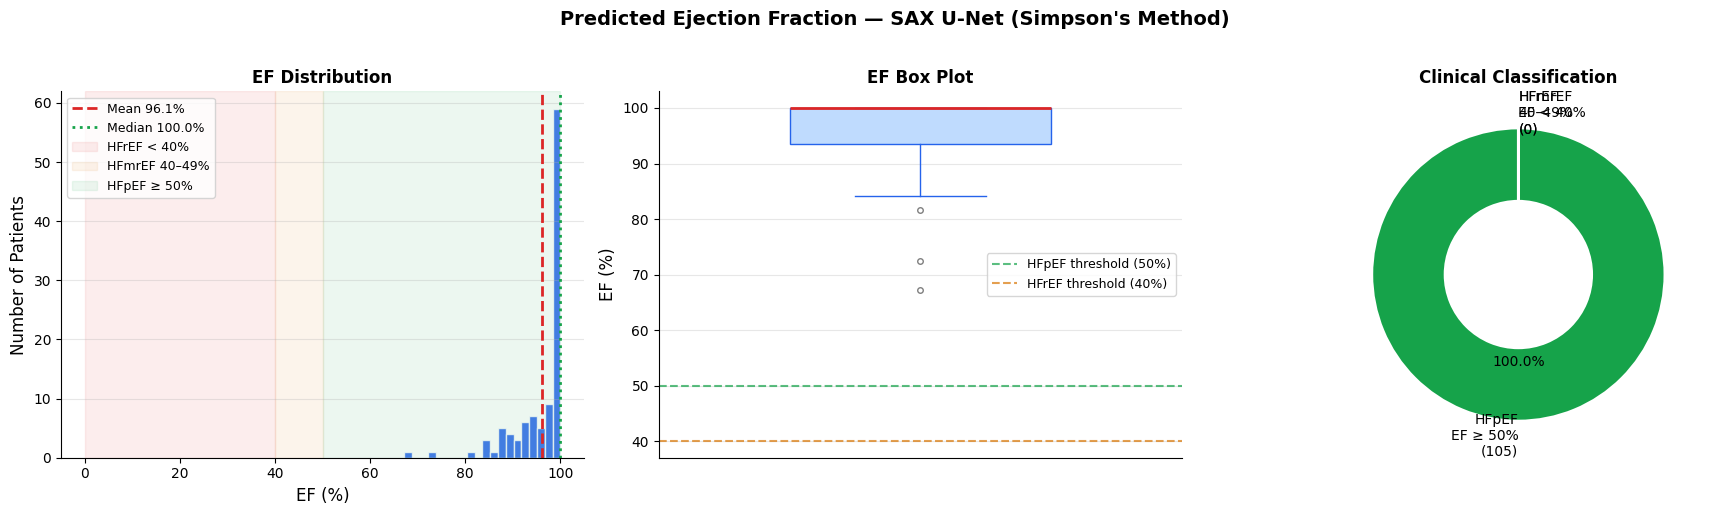

Chart saved → /kaggle/working/ef_distribution.png


In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Predicted Ejection Fraction — SAX U-Net (Simpson's Method)",
             fontsize=14, fontweight="bold", y=1.02)

# ── 1. Histogram ─────────────────────────────────────────────────────────────
ax = axes[0]
ax.hist(ef_vals, bins=20, color="#2563EB", edgecolor="white", alpha=0.85)
ax.axvline(ef_vals.mean(),   color="#DC2626", lw=2, linestyle="--", label=f"Mean {ef_vals.mean():.1f}%")
ax.axvline(np.median(ef_vals), color="#16A34A", lw=2, linestyle=":",  label=f"Median {np.median(ef_vals):.1f}%")
ax.axvspan(0,  40, alpha=0.08, color="#DC2626", label="HFrEF < 40%")
ax.axvspan(40, 50, alpha=0.08, color="#D97706", label="HFmrEF 40–49%")
ax.axvspan(50, 100,alpha=0.08, color="#16A34A", label="HFpEF ≥ 50%")
ax.set_xlabel("EF (%)", fontsize=12)
ax.set_ylabel("Number of Patients", fontsize=12)
ax.set_title("EF Distribution", fontsize=12, fontweight="bold")
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

# ── 2. Box plot ───────────────────────────────────────────────────────────────
ax = axes[1]
bp = ax.boxplot(ef_vals, patch_artist=True, widths=0.5,
                boxprops=dict(facecolor="#BFDBFE", color="#2563EB"),
                medianprops=dict(color="#DC2626", linewidth=2),
                whiskerprops=dict(color="#2563EB"),
                capprops=dict(color="#2563EB"),
                flierprops=dict(marker="o", color="#9CA3AF", alpha=0.5, markersize=4))
ax.axhline(50, color="#16A34A", lw=1.5, linestyle="--", alpha=0.7, label="HFpEF threshold (50%)")
ax.axhline(40, color="#D97706", lw=1.5, linestyle="--", alpha=0.7, label="HFrEF threshold (40%)")
ax.set_ylabel("EF (%)", fontsize=12)
ax.set_title("EF Box Plot", fontsize=12, fontweight="bold")
ax.set_xticks([])
ax.legend(fontsize=9)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

# ── 3. Clinical classification pie ───────────────────────────────────────────
ax = axes[2]
sizes  = [preserved, mildly_red, reduced]
labels = [f"HFpEF\nEF ≥ 50%\n({preserved})",
          f"HFmrEF\n40–49%\n({mildly_red})",
          f"HFrEF\nEF < 40%\n({reduced})"]
colors = ["#16A34A", "#D97706", "#DC2626"]
wedge_props = dict(width=0.5, edgecolor="white", linewidth=2)
ax.pie([s if s > 0 else 0.001 for s in sizes], labels=labels, colors=colors,
       autopct=lambda p: f"{p:.1f}%" if p > 0.5 else "",
       wedgeprops=wedge_props, startangle=90,
       textprops=dict(fontsize=10))
ax.set_title("Clinical Classification", fontsize=12, fontweight="bold")

plt.tight_layout()
chart_path = os.path.join(OUTPUT_DIR, "ef_distribution.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved → {chart_path}")

In [20]:
print(f"ef_predictions.json — {len(ef_sorted)} entries")
print()
# Print the first 5 entries as formatted JSON
preview = dict(list(ef_sorted.items())[:5])
print(json.dumps(preview, indent=2))
print("  ...")

ef_predictions.json — 105 entries

{
  "CINE_SAX_001": 100.0,
  "CINE_SAX_002": 100.0,
  "CINE_SAX_003": 98.38,
  "CINE_SAX_004": 100.0,
  "CINE_SAX_005": 94.54
}
  ...


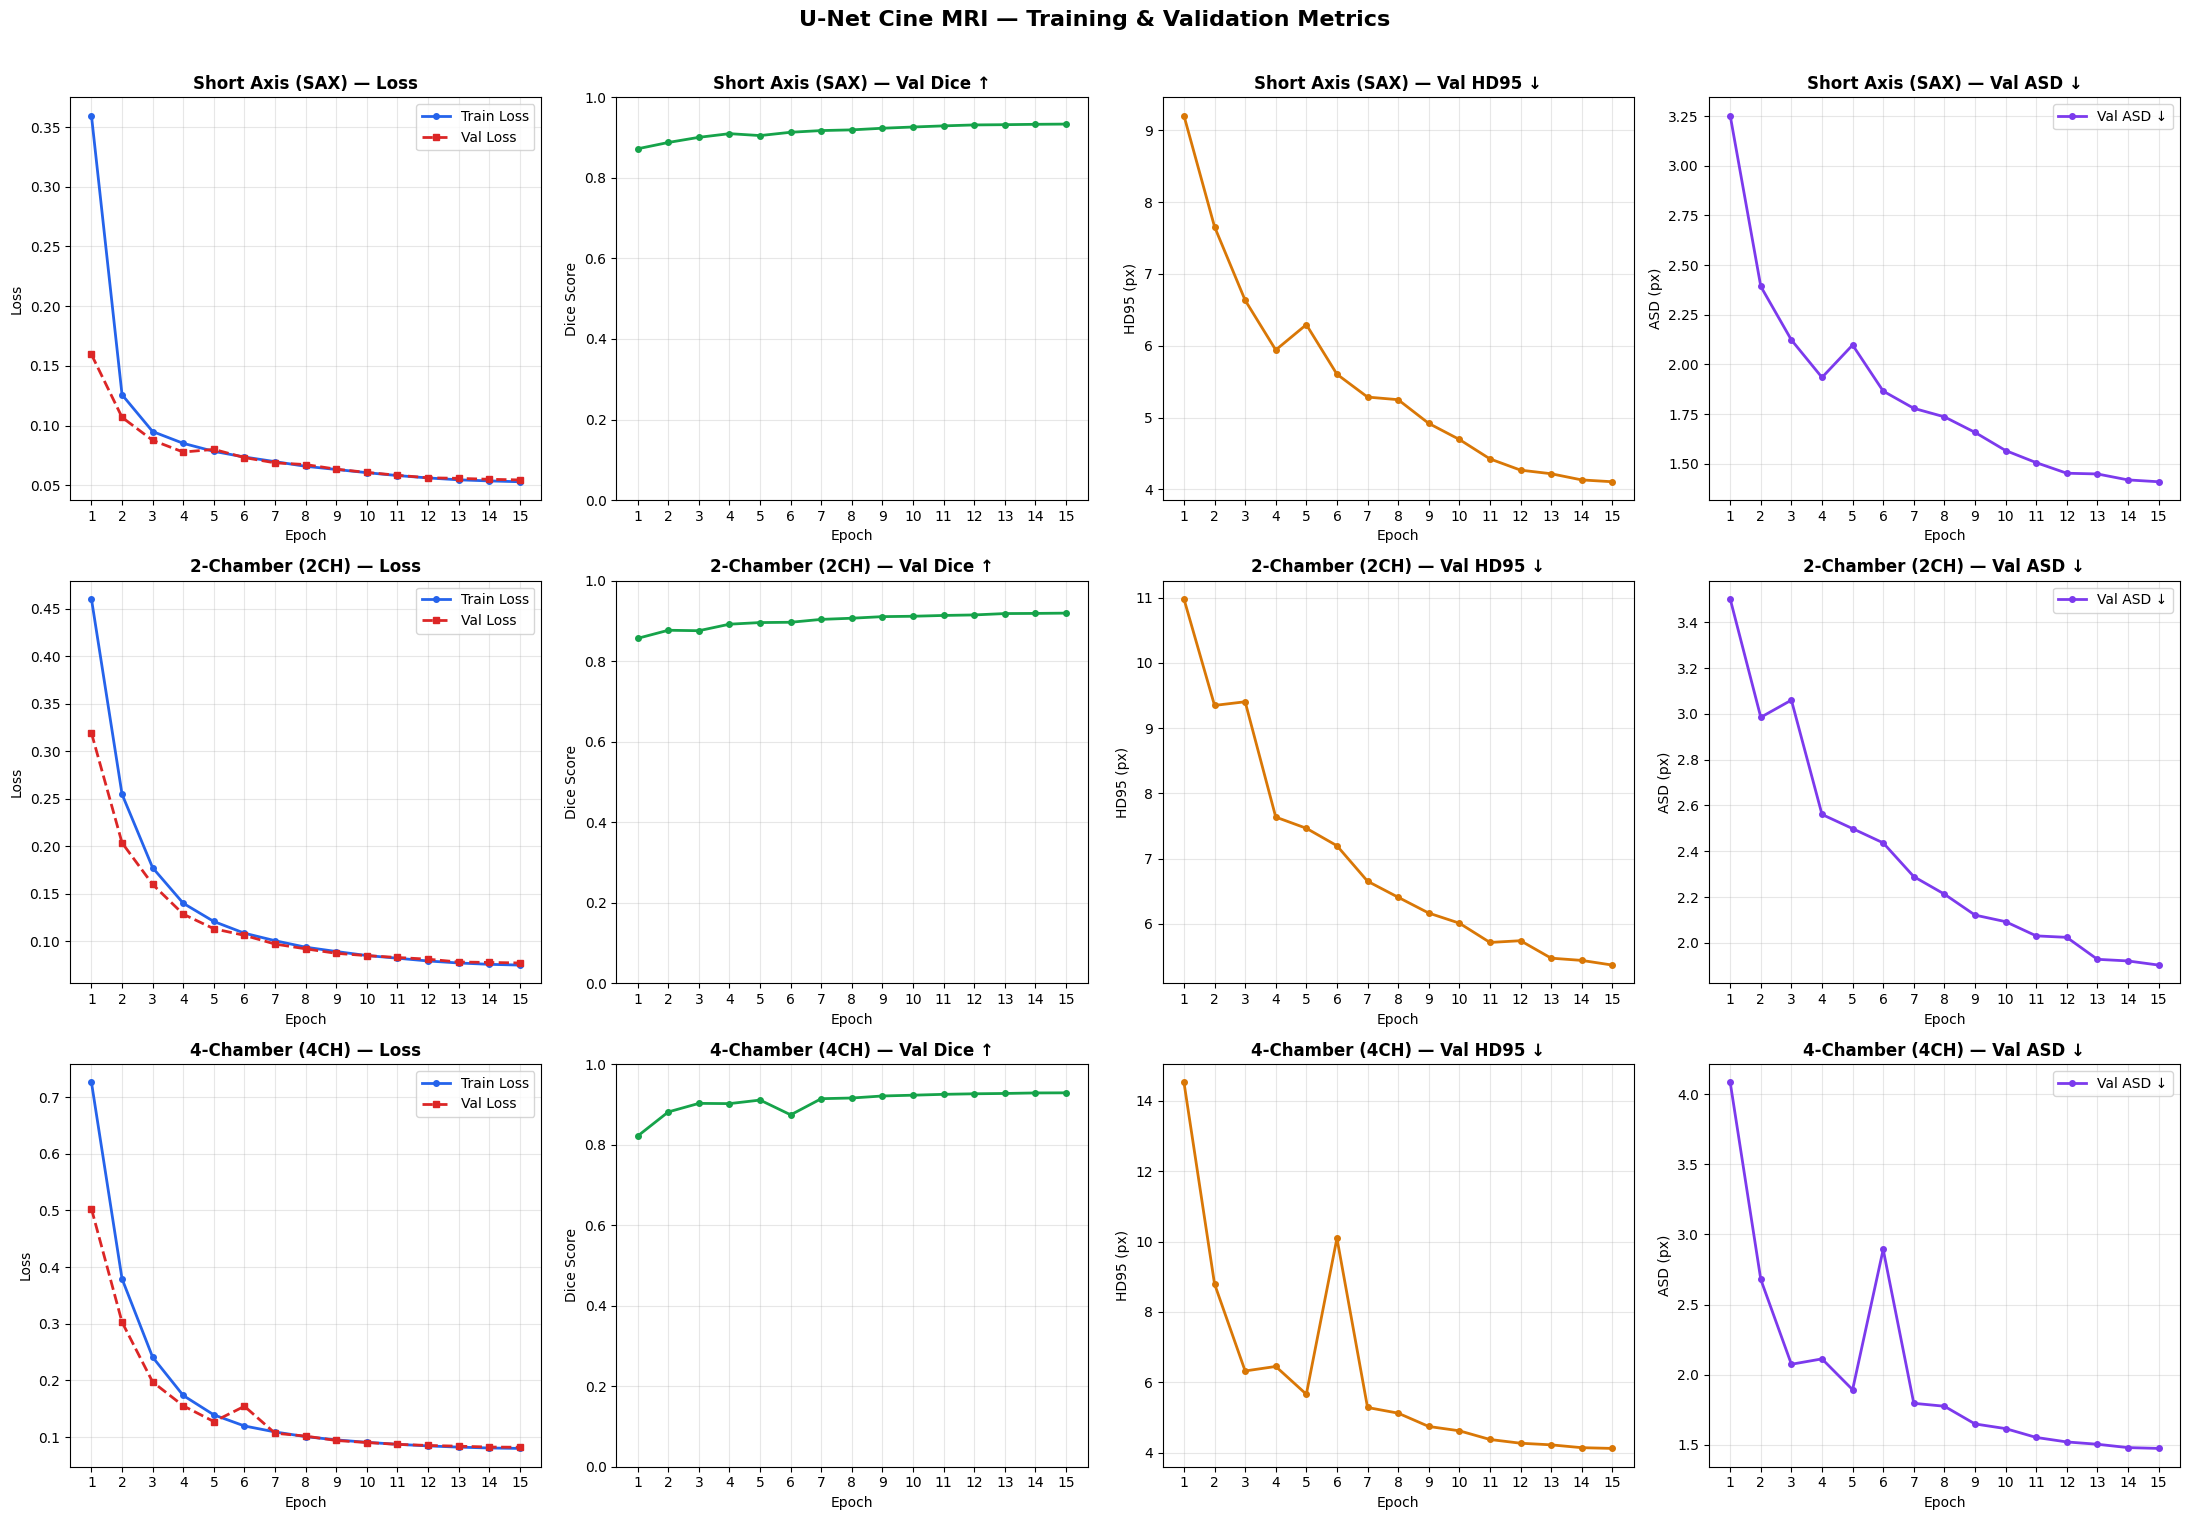

Chart saved → /kaggle/working/training_curves.png


In [13]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

VIEW_LABELS = {
    "SAX_TR": "Short Axis (SAX)",
    "2CH_TR": "2-Chamber (2CH)",
    "4CH_TR": "4-Chamber (4CH)",
}

COLORS = {
    "train": "#2563EB",   # blue
    "val":   "#DC2626",   # red
    "dice":  "#16A34A",   # green
    "hd95":  "#D97706",   # amber
    "asd":   "#7C3AED",   # violet
    "pcc":   "#0891B2",   # cyan
}

def plot_view_metrics(view, ax_loss, ax_dice, ax_hd, ax_extra):
    csv_path = os.path.join(OUTPUT_DIR, f"metrics_{view}.csv")
    df = pd.read_csv(csv_path)
    epochs = df["epoch"]
    label  = VIEW_LABELS[view]

    # ── Loss ─────────────────────────────────────────────────
    ax_loss.plot(epochs, df["train_loss"], color=COLORS["train"], lw=2, marker="o", ms=4, label="Train Loss")
    ax_loss.plot(epochs, df["val_loss"],   color=COLORS["val"],   lw=2, marker="s", ms=4, label="Val Loss",   linestyle="--")
    ax_loss.set_title(f"{label} — Loss", fontsize=12, fontweight="bold")
    ax_loss.set_xlabel("Epoch"); ax_loss.set_ylabel("Loss")
    ax_loss.legend(); ax_loss.grid(alpha=0.3)
    ax_loss.set_xticks(epochs)

    # ── Dice ─────────────────────────────────────────────────
    ax_dice.plot(epochs, df["val_dice"], color=COLORS["dice"], lw=2, marker="o", ms=4)
    ax_dice.set_title(f"{label} — Val Dice ↑", fontsize=12, fontweight="bold")
    ax_dice.set_xlabel("Epoch"); ax_dice.set_ylabel("Dice Score")
    ax_dice.set_ylim(0, 1); ax_dice.grid(alpha=0.3)
    ax_dice.set_xticks(epochs)

    # ── HD95 ─────────────────────────────────────────────────
    ax_hd.plot(epochs, df["val_hd95"], color=COLORS["hd95"], lw=2, marker="o", ms=4)
    ax_hd.set_title(f"{label} — Val HD95 ↓", fontsize=12, fontweight="bold")
    ax_hd.set_xlabel("Epoch"); ax_hd.set_ylabel("HD95 (px)")
    ax_hd.grid(alpha=0.3)
    ax_hd.set_xticks(epochs)

    # ── ASD / EF PCC ─────────────────────────────────────────
    ax_extra.plot(epochs, df["val_asd"], color=COLORS["asd"], lw=2, marker="o", ms=4, label="Val ASD ↓")
    if view == "SAX_TR" and df["ef_pcc"].notna().any():
        ax2 = ax_extra.twinx()
        ax2.plot(epochs, df["ef_pcc"], color=COLORS["pcc"], lw=2, marker="s", ms=4,
                 linestyle="--", label="EF PCC ↑")
        ax2.set_ylabel("EF PCC", color=COLORS["pcc"])
        ax2.tick_params(axis="y", labelcolor=COLORS["pcc"])
        lines2, labels2 = ax2.get_legend_handles_labels()
        lines1, labels1 = ax_extra.get_legend_handles_labels()
        ax_extra.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
        ax_extra.set_title(f"{label} — Val ASD & EF PCC", fontsize=12, fontweight="bold")
    else:
        ax_extra.legend()
        ax_extra.set_title(f"{label} — Val ASD ↓", fontsize=12, fontweight="bold")

    ax_extra.set_xlabel("Epoch"); ax_extra.set_ylabel("ASD (px)")
    ax_extra.grid(alpha=0.3)
    ax_extra.set_xticks(epochs)


fig, axes = plt.subplots(3, 4, figsize=(22, 15))
fig.suptitle("U-Net Cine MRI — Training & Validation Metrics", fontsize=16, fontweight="bold", y=1.01)

for row, view in enumerate(["SAX_TR", "2CH_TR", "4CH_TR"]):
    plot_view_metrics(view, axes[row, 0], axes[row, 1], axes[row, 2], axes[row, 3])

plt.tight_layout()
chart_path = os.path.join(OUTPUT_DIR, "training_curves.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved → {chart_path}")

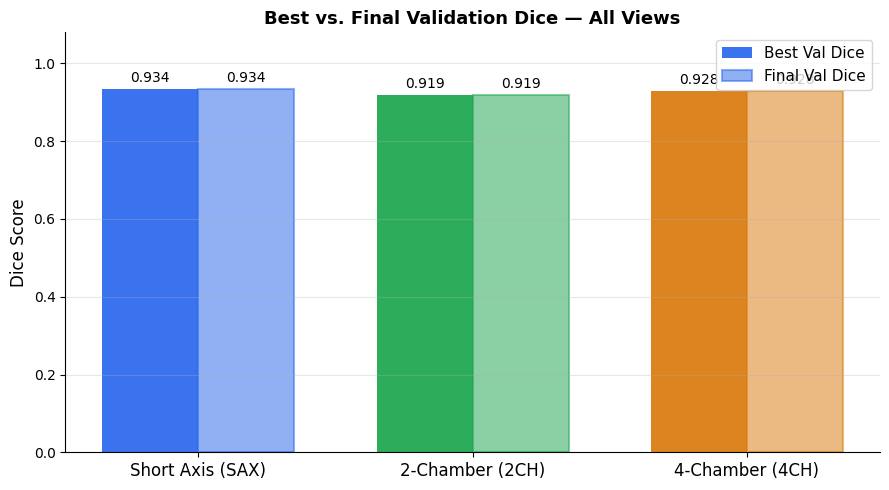

Chart saved → /kaggle/working/dice_summary.png


In [14]:
fig, ax = plt.subplots(figsize=(9, 5))

views     = ["SAX_TR", "2CH_TR", "4CH_TR"]
bar_colors = ["#2563EB", "#16A34A", "#D97706"]
x_labels  = ["Short Axis (SAX)", "2-Chamber (2CH)", "4-Chamber (4CH)"]

best_dices = []
final_dices = []

for view in views:
    df = pd.read_csv(os.path.join(OUTPUT_DIR, f"metrics_{view}.csv"))
    best_dices.append(df["val_dice"].max())
    final_dices.append(df["val_dice"].iloc[-1])

x     = np.arange(len(views))
width = 0.35

bars1 = ax.bar(x - width/2, best_dices,  width, label="Best Val Dice",  color=bar_colors, alpha=0.9)
bars2 = ax.bar(x + width/2, final_dices, width, label="Final Val Dice", color=bar_colors, alpha=0.5,
               edgecolor=[c for c in bar_colors], linewidth=1.5)

ax.bar_label(bars1,  fmt="%.3f", padding=3, fontsize=10)
ax.bar_label(bars2,  fmt="%.3f", padding=3, fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(x_labels, fontsize=12)
ax.set_ylabel("Dice Score", fontsize=12)
ax.set_ylim(0, 1.08)
ax.set_title("Best vs. Final Validation Dice — All Views", fontsize=13, fontweight="bold")
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
bar_path = os.path.join(OUTPUT_DIR, "dice_summary.png")
plt.savefig(bar_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Chart saved → {bar_path}")

In [15]:
import matplotlib.pyplot as plt

def visualize_prediction(model, dataset, idx=0):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    img, mask, _ = dataset[idx]

    with torch.no_grad():
        pred = model(
            img.unsqueeze(0).to(device)
        )

    pred = torch.argmax(pred, dim=1).squeeze().cpu().numpy()

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))

    ax[0].imshow(img.squeeze(), cmap="gray")
    ax[0].set_title("MRI")

    ax[1].imshow(mask.numpy())
    ax[1].set_title("Ground Truth")

    ax[2].imshow(pred)
    ax[2].set_title("Prediction")

    plt.show()


def evaluate_model(model_path, root_dir, view="SAX_TR", img_size=256):

    cfg = VIEW_CONFIG[view]
    num_classes = cfg["num_classes"]

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    dataset = CineMRIDataset(
        root_dir,
        view=view,
        img_size=img_size,
        augment=False
    )

    loader = DataLoader(
        dataset,
        batch_size=64,
        shuffle=False,
        num_workers=4,
        pin_memory=True
    )

    model = UNet(
        in_channels=1,
        out_channels=num_classes
    )
    

    model.load_state_dict(
        torch.load(model_path, map_location=device)
    )
    if torch.cuda.device_count() > 1:
      print(f"Using {torch.cuda.device_count()} GPUs")
      model = nn.DataParallel(model)

    model = model.to(device)
    model.eval()

    total_dice = 0
    total_hd = 0
    total_asd = 0
    count = 0

    with torch.no_grad():

        for imgs, masks, _ in tqdm(loader, desc=f"Evaluating {view}"):

            imgs = imgs.to(device)
            masks = masks.to(device)

            preds = model(imgs)

            total_dice += dice_score(
                preds,
                masks,
                num_classes
            ).item()

            pred_np = torch.argmax(preds, 1).cpu().numpy()
            mask_np = masks.cpu().numpy()

            for b in range(pred_np.shape[0]):

                hd, asd = hausdorff95_asd(
                    pred_np[b],
                    mask_np[b],
                    num_classes
                )

                if not np.isnan(hd):
                    total_hd += hd
                    total_asd += asd
                    count += 1

    avg_dice = total_dice / len(loader)
    avg_hd = total_hd / count
    avg_asd = total_asd / count

    print(f"\nResults for {view}")
    print(f"Dice Score : {avg_dice:.4f}")
    print(f"HD95       : {avg_hd:.4f}")
    print(f"ASD        : {avg_asd:.4f}")

    return model, dataset

In [16]:
ROOT = "/kaggle/input/datasets/youssefsharabas/cinemultii"

SAX_MODEL = "/kaggle/input/models/youssefsharabas/unet/pytorch/default/1/unet_SAX_TR_best.pth"

CH2_MODEL = "/kaggle/input/models/youssefsharabas/unet/pytorch/default/1/unet_2CH_TR_best.pth"

CH4_MODEL = "/kaggle/input/models/youssefsharabas/unet/pytorch/default/1/unet_4CH_TR_best.pth"

In [17]:
evaluate_model(SAX_MODEL, ROOT, "SAX_TR")

evaluate_model(CH2_MODEL, ROOT, "2CH_TR")

evaluate_model(CH4_MODEL, ROOT, "4CH_TR")

Using 2 GPUs


Evaluating SAX_TR: 100%|██████████| 463/463 [11:09<00:00,  1.45s/it]



Results for SAX_TR
Dice Score : 0.9113
HD95       : 3.9742
ASD        : 1.3507
Using 2 GPUs


Evaluating 2CH_TR: 100%|██████████| 134/134 [02:24<00:00,  1.08s/it]



Results for 2CH_TR
Dice Score : 0.9189
HD95       : 5.1108
ASD        : 1.8299
Using 2 GPUs


Evaluating 4CH_TR: 100%|██████████| 130/130 [03:19<00:00,  1.53s/it]


Results for 4CH_TR
Dice Score : 0.9281
HD95       : 3.9646
ASD        : 1.4240


(DataParallel(
   (module): UNet(
     (d1): DoubleConv(
       (conv): Sequential(
         (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (2): ReLU(inplace=True)
         (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (5): ReLU(inplace=True)
       )
     )
     (p1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
     (d2): DoubleConv(
       (conv): Sequential(
         (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (2): ReLU(inplace=True)
         (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (4)

Using 2 GPUs


Evaluating SAX_TR: 100%|██████████| 463/463 [11:10<00:00,  1.45s/it]



Results for SAX_TR
Dice Score : 0.9113
HD95       : 3.9742
ASD        : 1.3507


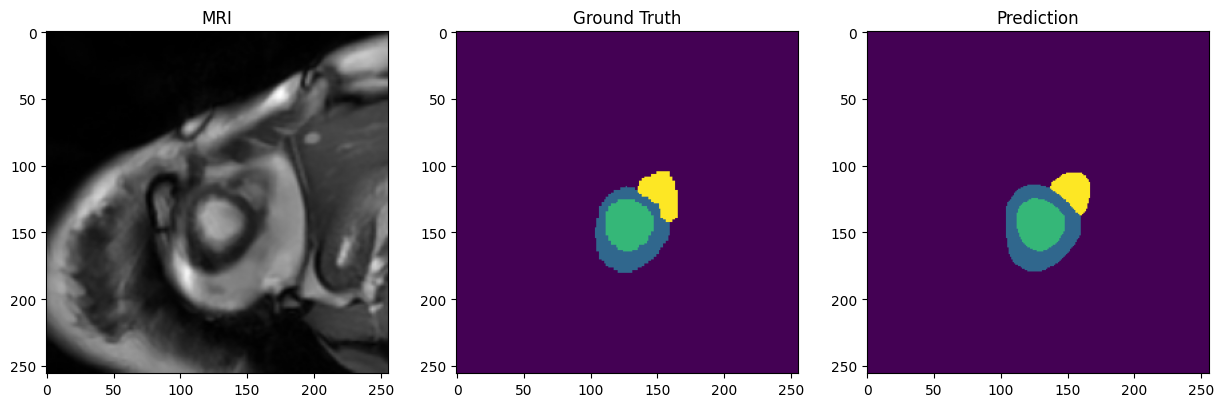

In [18]:
model, dataset = evaluate_model(
    SAX_MODEL,
    ROOT,
    "SAX_TR"
)

visualize_prediction(model, dataset, idx=50)

Using 2 GPUs


Evaluating 2CH_TR: 100%|██████████| 134/134 [02:28<00:00,  1.11s/it]



Results for 2CH_TR
Dice Score : 0.9189
HD95       : 5.1108
ASD        : 1.8299


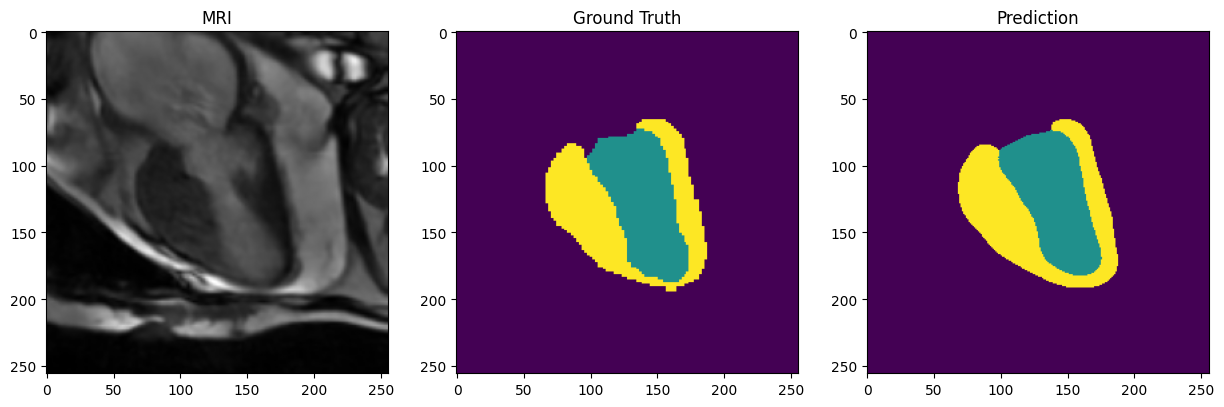

In [19]:
model_2ch, dataset_2ch = evaluate_model(
    CH2_MODEL,
    ROOT,
    "2CH_TR"
)

visualize_prediction(
    model_2ch,
    dataset_2ch,
    idx=50
)

Using 2 GPUs


Evaluating 4CH_TR: 100%|██████████| 130/130 [03:18<00:00,  1.53s/it]



Results for 4CH_TR
Dice Score : 0.9281
HD95       : 3.9646
ASD        : 1.4240


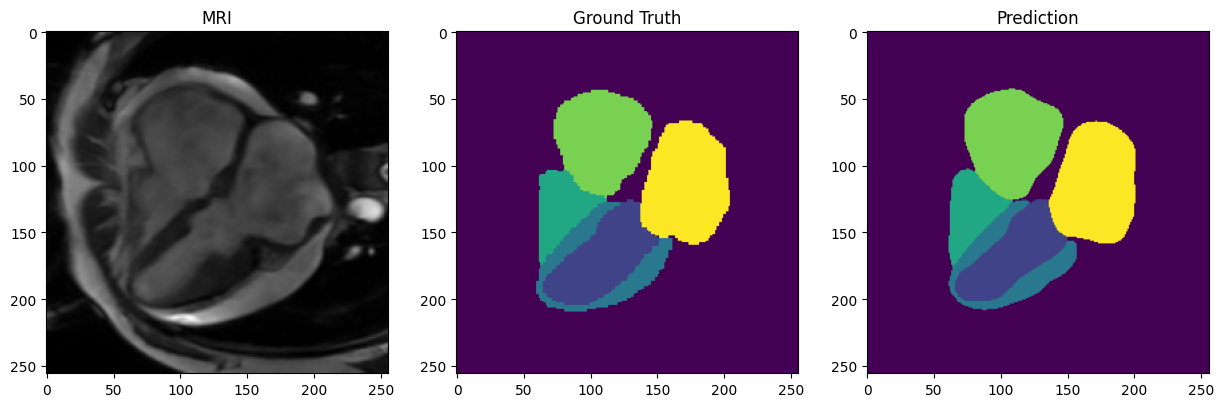

In [20]:
model_4ch, dataset_4ch = evaluate_model(
    CH4_MODEL,
    ROOT,
    "4CH_TR"
)

visualize_prediction(
    model_4ch,
    dataset_4ch,
    idx=50
)